In [15]:

#%pip install mpld3
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [16]:

df = pd.read_csv("../data/processed/311_noise_cleaned.csv", parse_dates=["Created Date"])

In [17]:
# Label each complaint by COVID era for use in the analyses below
def covid_era(d):
    if d < pd.Timestamp('2020-03-01'):
        return 'Pre-COVID'
    elif d < pd.Timestamp('2021-07-01'):
        return 'Lockdown'
    else:
        return 'Post-COVID'

df['Era'] = df['Created Date'].map(covid_era)

complaint types

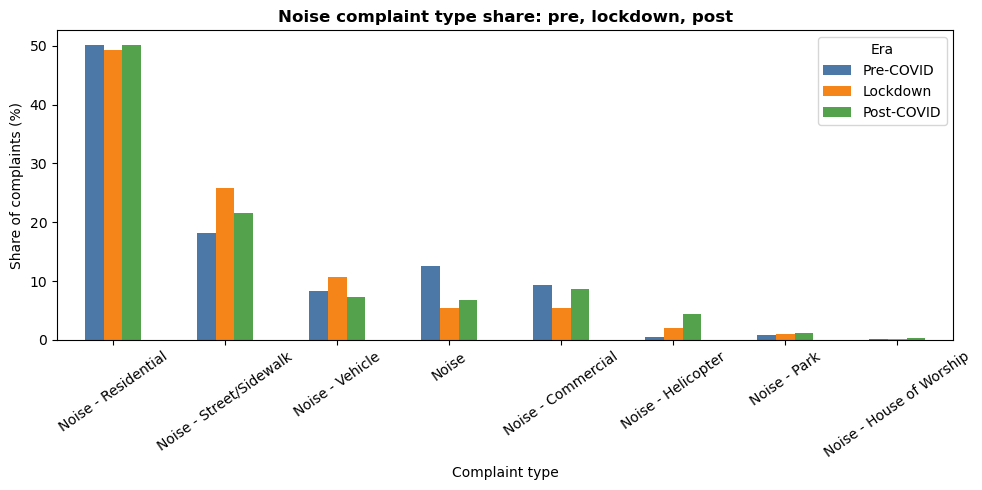

In [18]:
type_col = 'Complaint Type'
era_focus = df[df['Era'].isin(['Pre-COVID', 'Lockdown', 'Post-COVID'])]

share = (
    era_focus.groupby(['Era', type_col]).size()
    .groupby(level=0, group_keys=False)
    .apply(lambda s: s / s.sum() * 100)
    .unstack(fill_value=0)
 )

top_types = (
    share.loc['Pre-COVID'] + share.loc['Lockdown'] + share.loc['Post-COVID']
 ).sort_values(ascending=False).head(8).index
plot_df = share[top_types].T[['Pre-COVID', 'Lockdown', 'Post-COVID']]

fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind='bar', ax=ax, color=['#4c78a8', '#f58518', '#54a24b'])
ax.set_title('Noise complaint type share: pre, lockdown, post', fontweight='bold')
ax.set_ylabel('Share of complaints (%)')
ax.set_xlabel('Complaint type')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='Era')
plt.tight_layout()
plt.show()

In [19]:
import plotly.express as px

# plot_df is already in the right format: complaint types as index, eras as columns
fig = px.bar(
    plot_df,
    x=plot_df.index,
    y=['Pre-COVID', 'Lockdown', 'Post-COVID'],
    labels={'value': 'Share of complaints (%)', 'x': 'Complaint type', 'variable': 'Era'},
    barmode='group',
    color_discrete_sequence=['#4c78a8', '#f58518', '#54a24b'],
    title='Noise complaint type share: pre, lockdown, post'
)
fig.update_layout(xaxis_tickangle=35)
fig.write_html("C:\\git\\sda_final_project\\types_of_complaints.html")

Sub-lead: A brief paragraph explaining how the city transitioned from pre-2020 levels to a permanent "New Normal"

Average complaints per month by era:
Era
Pre-COVID     37333
Lockdown      69074
Post-COVID    62824

Lockdown vs pre:   +85.0%
Post-COVID vs pre: +68.3%


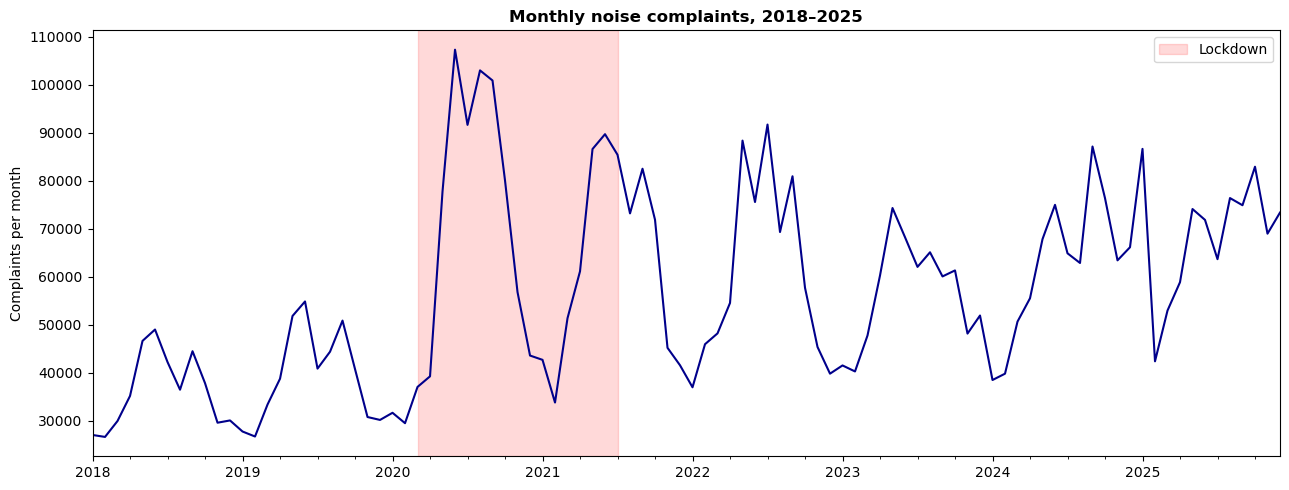

In [20]:
# 1 & 2: monthly complaint rate by era
monthly = df.set_index('Created Date').resample('MS').size()
era_monthly = df.groupby('Era').size() / df.groupby('Era')['Created Date'].apply(
    lambda s: (s.max() - s.min()).days / 30.44
)
era_monthly = era_monthly.round(0).astype(int).reindex(['Pre-COVID', 'Lockdown', 'Post-COVID'])

print("Average complaints per month by era:")
print(era_monthly.to_string())

pre = era_monthly['Pre-COVID']
lock = era_monthly['Lockdown']
post = era_monthly['Post-COVID']
print(f"\nLockdown vs pre:   {(lock/pre - 1)*100:+.1f}%")
print(f"Post-COVID vs pre: {(post/pre - 1)*100:+.1f}%")

# Plot the monthly series with era shading
fig, ax = plt.subplots(figsize=(13, 5))
monthly.plot(ax=ax, color='darkblue', linewidth=1.5)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-07-01'),
           alpha=0.15, color='red', label='Lockdown')
ax.set_title('Monthly noise complaints, 2018–2025', fontweight='bold')
ax.set_ylabel('Complaints per month')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:

fig = px.line(monthly, labels={'value': 'Complaints per month', 'Created Date': 'Date'})
fig.write_html("C:\\git\\sda_final_project\\complaints_over_time.html")

# Daily Patterns

In [22]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
eras = ['Pre-COVID', 'Lockdown', 'Post-COVID']

# Create subplots: 1 row, 3 columns
fig = make_subplots(rows=1, cols=3, subplot_titles=eras, shared_yaxes=True)

for i, era in enumerate(eras):
    era_df = df[df['Era'] == era]
    heatmap = (
        era_df.assign(
            dow=era_df['Created Date'].dt.day_name(),
            hour=era_df['Created Date'].dt.hour,
        )
        .pivot_table(index='dow', columns='hour', values='Borough',
                     aggfunc='count', fill_value=0)
        .reindex(day_order)
    )
    n_days = (era_df['Created Date'].max() - era_df['Created Date'].min()).days
    heatmap = heatmap / n_days * 7  # avg per weekday slot

    fig.add_trace(
        go.Heatmap(
            z=heatmap.values,
            x=heatmap.columns,
            y=heatmap.index,
            colorscale='YlOrRd',
            colorbar=dict(title='Avg complaints') if i == 2 else None,
        ),
        row=1, col=i+1
    )

fig.update_layout(
    title_text='Day-of-week × hour, by COVID era',
    height=500, width=1200,
    showlegend=False,
    margin=dict(t=80)
)
fig.write_html("C:\\git\\sda_final_project\\daily_patterns.html")

Noise complaints per 1,000 residents (2018–2025 total):
               Complaints  Population  Per 1,000 residents
Borough                                                   
BRONX             1518408     1472654                 1031
MANHATTAN         1438048     1694251                  849
BROOKLYN          1360173     2736074                  497
QUEENS            1024790     2405464                  426
STATEN ISLAND      120001      495747                  242


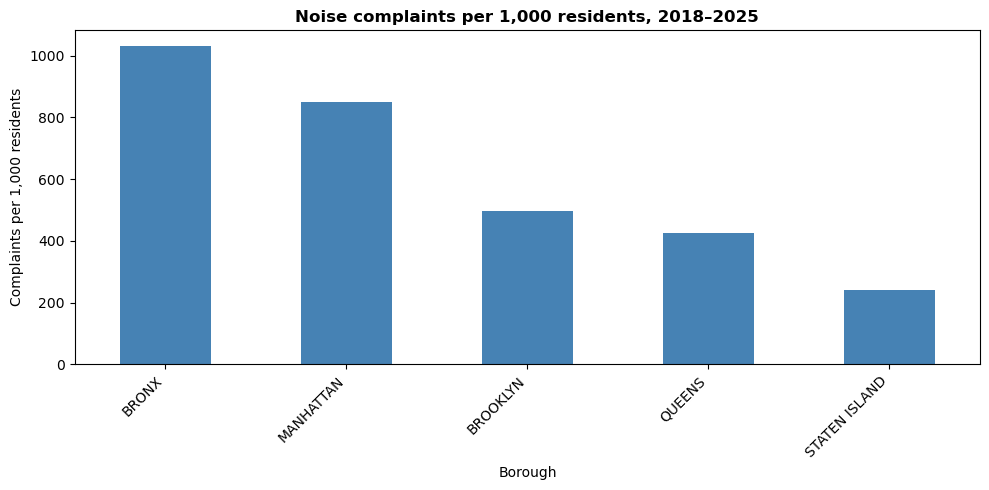

In [23]:
# 2020 US Census borough populations, used for per-capita rates in Q2
borough_pop = {
    'BRONX':         1_472_654,
    'BROOKLYN':      2_736_074,
    'MANHATTAN':     1_694_251,
    'QUEENS':        2_405_464,
    'STATEN ISLAND':   495_747,
}
# Per-capita complaint rate by borough
borough_counts = df['Borough'].value_counts()
borough_df = pd.DataFrame({
    'Complaints': borough_counts,
    'Population': [borough_pop[b] for b in borough_counts.index],
})
borough_df['Per 1,000 residents'] = (
    borough_df['Complaints'] / borough_df['Population'] * 1000
).round(0).astype(int)
borough_df = borough_df.sort_values('Per 1,000 residents', ascending=False)
print("Noise complaints per 1,000 residents (2018–2025 total):")
print(borough_df.to_string())

# Plot: per-capita bar chart
fig, ax = plt.subplots(figsize=(10, 5))
borough_df['Per 1,000 residents'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Noise complaints per 1,000 residents, 2018–2025',
             fontweight='bold')
ax.set_ylabel('Complaints per 1,000 residents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:


fig = px.bar(
    borough_df,
    x=borough_df.index,
    y='Per 1,000 residents',
    labels={'x': 'Borough', 'Per 1,000 residents': 'Complaints per 1,000 residents'},
    color_discrete_sequence=['steelblue'],
    title='Noise complaints per 1,000 residents, 2018–2025'
)
fig.update_layout(xaxis_tickangle=45)
fig.write_html("C:\\git\\sda_final_project\\complaints_per_capita.html")

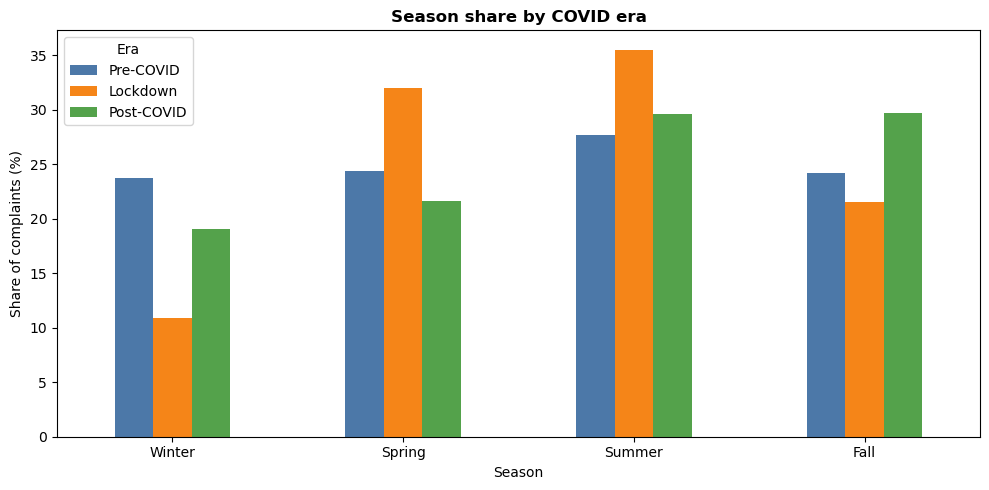

In [25]:
# Seasonal share by COVID era
season_map = {1: 'Winter', 2: 'Winter', 12: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
era_order = ['Pre-COVID', 'Lockdown', 'Post-COVID']

season_era = df[df['Era'].isin(era_order)].copy()
season_era['Season'] = season_era['Created Date'].dt.month.map(season_map)

share = (
    season_era.groupby(['Era', 'Season']).size()
    .groupby(level=0, group_keys=False)
    .apply(lambda s: s / s.sum() * 100)
    .unstack(fill_value=0)
)
share = share.reindex(index=era_order, columns=season_order)

fig, ax = plt.subplots(figsize=(10, 5))
share.T.plot(kind='bar', ax=ax, color=['#4c78a8', '#f58518', '#54a24b'])
ax.set_title('Season share by COVID era', fontweight='bold')
ax.set_ylabel('Share of complaints (%)')
ax.set_xlabel('Season')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Era')
plt.tight_layout()
plt.show()

fig = px.bar(
    share.T,
    x=share.T.index,
    y=['Pre-COVID', 'Lockdown', 'Post-COVID'],
    labels={'value': 'Share of complaints (%)', 'x': 'Season', 'variable': 'Era'},
    barmode='group',
    color_discrete_sequence=['#4c78a8', '#f58518', '#54a24b'],
    title='Season share by COVID era'
)
fig.update_layout(xaxis_tickangle=0)
fig.write_html("C:\\git\\sda_final_project\\seasonal_share.html")


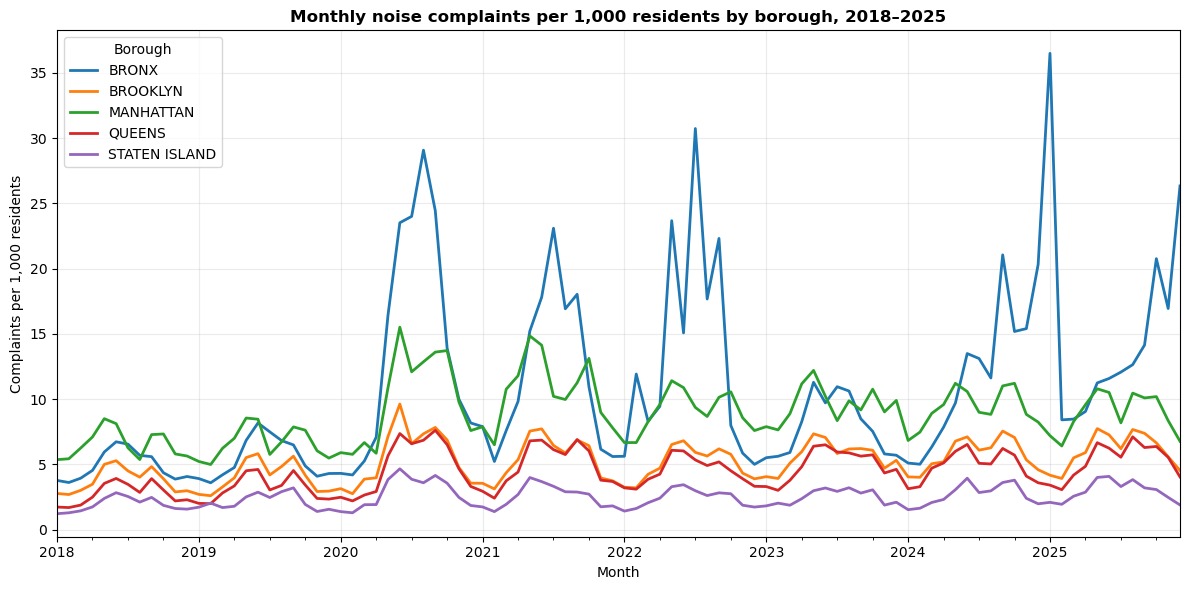

In [26]:
# Monthly per-capita complaint trend by borough
borough_time_df = (
    df.assign(Month=df['Created Date'].dt.to_period('M').dt.to_timestamp())
    .groupby(['Month', 'Borough']).size()
    .reset_index(name='Complaints')
)
borough_time_df['Population'] = borough_time_df['Borough'].map(borough_pop)
borough_time_df['Per 1,000 residents'] = (
    borough_time_df['Complaints'] / borough_time_df['Population'] * 1000
).round(2)
borough_time_pivot = borough_time_df.pivot(index='Month', columns='Borough', values='Per 1,000 residents')
borough_time_pivot = borough_time_pivot.reindex(columns=['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND'])

fig, ax = plt.subplots(figsize=(12, 6))
borough_time_pivot.plot(ax=ax, linewidth=2)
ax.set_title('Monthly noise complaints per 1,000 residents by borough, 2018–2025', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Complaints per 1,000 residents')
ax.legend(title='Borough')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

fig = px.line(
    borough_time_df,
    x='Month',
    y='Per 1,000 residents',
    color='Borough',
    labels={'Month': 'Month', 'Per 1,000 residents': 'Complaints per 1,000 residents'},
    title='Monthly noise complaints per 1,000 residents by borough, 2018–2025'
)
fig.write_html("C:\\git\\sda_final_project\\borough_trends.html")

# Interactive maps

In [29]:
import json
import pandas as pd
import plotly.express as px

agg = (
    df.groupby(['Borough', 'Complaint description', 'Era'])
    .size()
    .reset_index(name='Count')
)
boroname_map = {'MANHATTAN': 'Manhattan', 'BRONX': 'Bronx', 'BROOKLYN': 'Brooklyn',
                'QUEENS': 'Queens', 'STATEN ISLAND': 'Staten Island'}
agg['Borough_geo'] = agg['Borough'].map(boroname_map)

with open('C:/git/sda_final_project/notebook/Borough_Boundaries_20260429.geojson', 'r') as f:
    geojson = json.load(f)

# Keep only complaint types that have data in all 3 eras (prevents blank maps)
era_coverage = (
    agg.groupby(['Complaint description', 'Era'])['Count'].sum()
    .unstack(fill_value=0)
)
valid_descs = sorted(
    era_coverage[era_coverage[['Pre-COVID', 'Lockdown', 'Post-COVID']].gt(0).all(axis=1)].index
)

agg = agg[agg['Complaint description'].isin(valid_descs)]

all_boroughs = pd.DataFrame({'Borough_geo': ['Manhattan', 'Bronx', 'Brooklyn', 'Queens', 'Staten Island']})

def get_data(complaint_desc, complaint_era):
    subset = agg[(agg['Complaint description'] == complaint_desc) & (agg['Era'] == complaint_era)]
    # Always return all 5 boroughs — missing ones get 0 instead of blank map
    return all_boroughs.merge(subset[['Borough_geo', 'Count']], on='Borough_geo', how='left').fillna(0)

desc = 'Loud Music/Party'
era  = 'Pre-COVID'
eras = ['Pre-COVID', 'Lockdown', 'Post-COVID']

filtered = get_data(desc, era)

fig = px.choropleth(
    filtered,
    geojson=geojson,
    locations='Borough_geo',
    featureidkey='properties.boroname',
    color='Count',
    color_continuous_scale='YlOrRd',
    labels={'Count': 'Complaints'},
)
fig.update_geos(fitbounds="locations", visible=False)

buttons_desc = []
for d in valid_descs:
    df_d = get_data(d, era)
    buttons_desc.append(dict(
        label=d, method='update',
        args=[{'z': [df_d['Count'].tolist()], 'locations': [df_d['Borough_geo'].tolist()]},
              {'title.text': f'NYC Noise Complaints: {d} ({era})'}]))

buttons_era = []
for e in eras:
    df_e = get_data(desc, e)
    buttons_era.append(dict(
        label=e, method='update',
        args=[{'z': [df_e['Count'].tolist()], 'locations': [df_e['Borough_geo'].tolist()]},
              {'title.text': f'NYC Noise Complaints: {desc} ({e})'}]))

fig.update_layout(
    title=dict(
        text=f'NYC Noise Complaints: {desc} ({era})',
        x=0.5, xanchor='center',
        y=0.97, yanchor='top',
        font=dict(size=18)
    ),
    updatemenus=[
        dict(buttons=buttons_desc, direction='down', showactive=True,
             x=0.05, xanchor='left', y=1.12, yanchor='top', bgcolor='white'),
        dict(buttons=buttons_era,  direction='down', showactive=True,
             x=0.55, xanchor='left', y=1.12, yanchor='top', bgcolor='white'),
    ],
    annotations=[
        dict(text='<b>Complaint type:</b>', x=0.05, y=1.12, yanchor='bottom',
             xref='paper', yref='paper', showarrow=False, align='left'),
        dict(text='<b>Era:</b>', x=0.55, y=1.12, yanchor='bottom',
             xref='paper', yref='paper', showarrow=False, align='left'),
    ],
    autosize=True,
    margin={"r": 0, "t": 120, "l": 0, "b": 0}
)

fig.write_html(
    "C:\\git\\sda_final_project\\interactive_noise_map.html",
    config={"responsive": True},
    post_script="document.documentElement.style.height='100%';"
                "document.body.style.height='100%';"
                "document.body.style.margin='0';"
                "document.querySelector('.plotly-graph-div').style.height='100vh';",
)


More Interactive plot

In [28]:
import pandas as pd
import plotly.express as px
import json
from shapely.geometry import Point, shape
from shapely.strtree import STRtree
import numpy as np

with open('NYC_Neighborhoods.geojson', 'r') as f:
    nta_geojson = json.load(f)

nta_geoms     = [shape(f['geometry']) for f in nta_geojson['features']]
nta_names_list = [f['properties']['NTAName'] for f in nta_geojson['features']]
tree = STRtree(nta_geoms)

def find_neighborhood(lat, lon):
    point = Point(lon, lat)
    idx = tree.nearest(point)
    if isinstance(idx, (int, np.integer)):
        return nta_names_list[idx] if nta_geoms[idx].contains(point) else None
    return None

df['Year'] = df['Created Date'].dt.year

top_noise_types = df['Complaint Type'].value_counts().nlargest(5).index.tolist()
df_filtered = df[df['Complaint Type'].isin(top_noise_types)].copy()
df_filtered['Neighborhood'] = df_filtered.apply(
    lambda r: find_neighborhood(r['Latitude'], r['Longitude']), axis=1
)
df_mapped = df_filtered.dropna(subset=['Neighborhood']).copy()

agg = (
    df_mapped.groupby(['Neighborhood', 'Year', 'Complaint Type'])
    .size()
    .reset_index(name='Count')
)

# Most frequent noise type per neighborhood + year
top_type = (
    agg.loc[agg.groupby(['Neighborhood', 'Year'])['Count'].idxmax(),
            ['Neighborhood', 'Year', 'Complaint Type']]
    .rename(columns={'Complaint Type': 'Top Type'})
)

# One row per (Neighborhood, Year): total count + top type for hover
agg_total = (
    agg.groupby(['Neighborhood', 'Year'])['Count']
    .sum()
    .reset_index()
    .merge(top_type, on=['Neighborhood', 'Year'])
)

HOVER = (
    '<b>%{hovertext}</b><br>'
    'Complaints: %{customdata[1]:.0f}<br>'
    'Most frequent type: %{customdata[0]}'
    '<extra></extra>'
)

fig = px.choropleth_mapbox(
    agg_total,
    geojson=nta_geojson,
    locations='Neighborhood',
    featureidkey="properties.NTAName",
    color='Count',
    animation_frame='Year',
    hover_name='Neighborhood',
    custom_data=['Top Type', 'Count'],
    color_continuous_scale="Viridis",
    range_color=[0, agg_total['Count'].quantile(0.95)],
    mapbox_style="carto-positron",
    zoom=9.5,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    labels={'Count': 'Complaints'},
    title='NYC Noise Complaints by Neighborhood'
)

# Base trace + every animation frame need the template set explicitly
fig.update_traces(hovertemplate=HOVER)
for frame in fig.frames:
    frame.data[0].update(hovertemplate=HOVER)

unique_types = agg['Complaint Type'].unique()
buttons = [
    dict(method="restyle", label=n_type,
         args=[{"z": [agg[agg['Complaint Type'] == n_type]['Count']]}])
    for n_type in unique_types
]

fig.update_layout(
    updatemenus=[dict(buttons=buttons, direction="down",
                      showactive=True, x=0.1, y=1.15)],
    margin={"r": 0, "t": 40, "l": 0, "b": 0}
)

fig.write_html('C:\\git\\sda_final_project\\neighborhood_comparison.html')